# Transiente con CI = solución estacionaria explosiva

**Objetivo**: Partir del estado estacionario (solución explosiva de `RIconduitex5_5_f`) como
condición inicial del modelo transiente. Esto permite:

1. **Test de consistencia**: si el modelo transiente es correcto, la solución debe
   *permanecer estacionaria* (sin deriva temporal).
2. **Análisis de estabilidad**: perturbar la CI y ver si el sistema regresa al estado
   explosivo o diverge.
3. **Evitar el spin-up** desde φ=0: la solución ya tiene el perfil de fragmentación
   correcto desde t=0.

**Flujo del notebook**:
```
RIconduitex5_5_f  →  zsol, sol  →  interpolar a grilla uniforme  →  CI transiente
RIconduit1D_transient_f(stationary_IC=...)  →  evolución temporal
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextlib, os, sys

sys.path.insert(0, os.getcwd())

from calbuco2015d         import *           # parámetros Calbuco 2015
from RIconduitex5_5       import RIconduitex5_5_f
from RIconduit1D_transient import (
    RIconduit1D_transient_f,
    _find_q, _pressure_march,
    Patm, g, rcrust, H, C1, beta, R
)

# Parámetros Calbuco
radius1 = radius1
overP1  = overP1
h2o1    = h2o1
T1      = T1
xi1     = xi1

print('Parámetros Calbuco 2015:')
print(f'  radio        = {radius1} m')
print(f'  sobrepresion = {overP1/1e6:.1f} MPa')
print(f'  H2O          = {h2o1} wt%')
print(f'  T            = {T1-273.15:.0f} C')
print(f'  xi           = {xi1}')
print(f'  phicrit (input) = {phicrit}')

Parámetros Calbuco 2015:
  radio        = 16 m
  sobrepresion = 5.0 MPa
  H2O          = 4 wt%
  T            = 970 C
  xi           = 0.25
  phicrit (input) = 0.8


## 1. Modelo estacionario

In [3]:
with open(os.devnull, 'w') as f:
    with contextlib.redirect_stdout(f):
        result_stat = RIconduitex5_5_f(radius1, overP1, h2o1, T1, xi1)

# Desempaquetar: [zsol, sol, count, vinicial, rho_m, rbub, visctot, rho_ti,
#                 fragcrit, phicrit, limphi1, limphi2, co, xi, xfinal, cg]
zsol        = result_stat[0]   # profundidades (m), de H a 0
sol         = result_stat[1]   # sol[:,0]=P  [:,1]=phi  [:,2]=Nd  [:,3]=x  [:,4]=um  [:,5]=ug
count       = result_stat[2]
vinicial_conv = result_stat[3]
rho_m       = result_stat[4]
phicrit_calc  = result_stat[9]   # phicrit calculado por formula Ca
co_stat     = result_stat[12]
xi_stat     = result_stat[13]

print(f'Modelo estacionario convergido en {count} iteraciones')
print(f'vinicial_conv  = {vinicial_conv:.4f} m/s')
print(f'phi_crit (Ca)  = {phicrit_calc:.4f}')
print(f'phi_vent       = {sol[-1,1]:.4f}')
print(f'P_vent         = {sol[-1,0]/1e5:.2f} bar')
print(f'um_vent        = {sol[-1,4]:.1f} m/s')
print(f'Puntos en sol  = {len(zsol)}')

Modelo estacionario convergido en 19 iteraciones
vinicial_conv  = 18.3334 m/s
phi_crit (Ca)  = 0.5795
phi_vent       = 0.9207
P_vent         = 13.76 bar
um_vent        = 223.1 m/s
Puntos en sol  = 17893


## 2. Interpolación a grilla uniforme del transiente

In [4]:
N_z  = 200
z_uniform = np.linspace(H, 0.0, N_z)   # misma grilla que usará el transiente

# La solución estacionaria puede tener z en orden descendente (H → 0 o 0 → H)
# Aseguramos orden ascendente para np.interp
if zsol[0] > zsol[-1]:          # si viene de 0 a H (descendente)
    zsol_asc = zsol[::-1]
    sol_asc  = sol[::-1]
else:
    zsol_asc = zsol
    sol_asc  = sol

# Interpolar φ, Nd, x en la grilla uniforme
phi_ic = np.interp(z_uniform, zsol_asc, sol_asc[:, 1])  # fraccion de gas
Nd_ic  = np.interp(z_uniform, zsol_asc, sol_asc[:, 2])  # densidad de burbujas
x_ic   = np.interp(z_uniform, zsol_asc, sol_asc[:, 3])  # fraccion de cristales

# Clip para seguridad
phi_ic = np.clip(phi_ic, 0.0, 0.99)
Nd_ic  = np.maximum(Nd_ic, 1e4)

# Nodos fragmentados en la CI
nfrag_ic = int(np.sum(phi_ic >= phicrit_calc))
z_frag_ic = z_uniform[phi_ic >= phicrit_calc]

print(f'Grilla transiente: N_z={N_z}, dz={z_uniform[1]-z_uniform[0]:.1f} m')
print(f'phi_ic: min={phi_ic.min():.4f}  max={phi_ic.max():.4f}')
print(f'Nd_ic : min={Nd_ic.min():.2e}  max={Nd_ic.max():.2e}')
print(f'x_ic  : min={x_ic.min():.4f}  max={x_ic.max():.4f}')
print(f'Nodos fragmentados en CI: {nfrag_ic}/{N_z}')
if nfrag_ic > 0:
    print(f'Profundidad inicio frag: {z_frag_ic[0]/1e3:.2f} km')

Grilla transiente: N_z=200, dz=35.2 m
phi_ic: min=0.0000  max=0.9207
Nd_ic : min=3.44e+13  max=3.44e+13
x_ic  : min=0.2500  max=0.2526
Nodos fragmentados en CI: 38/200
Profundidad inicio frag: -1.30 km


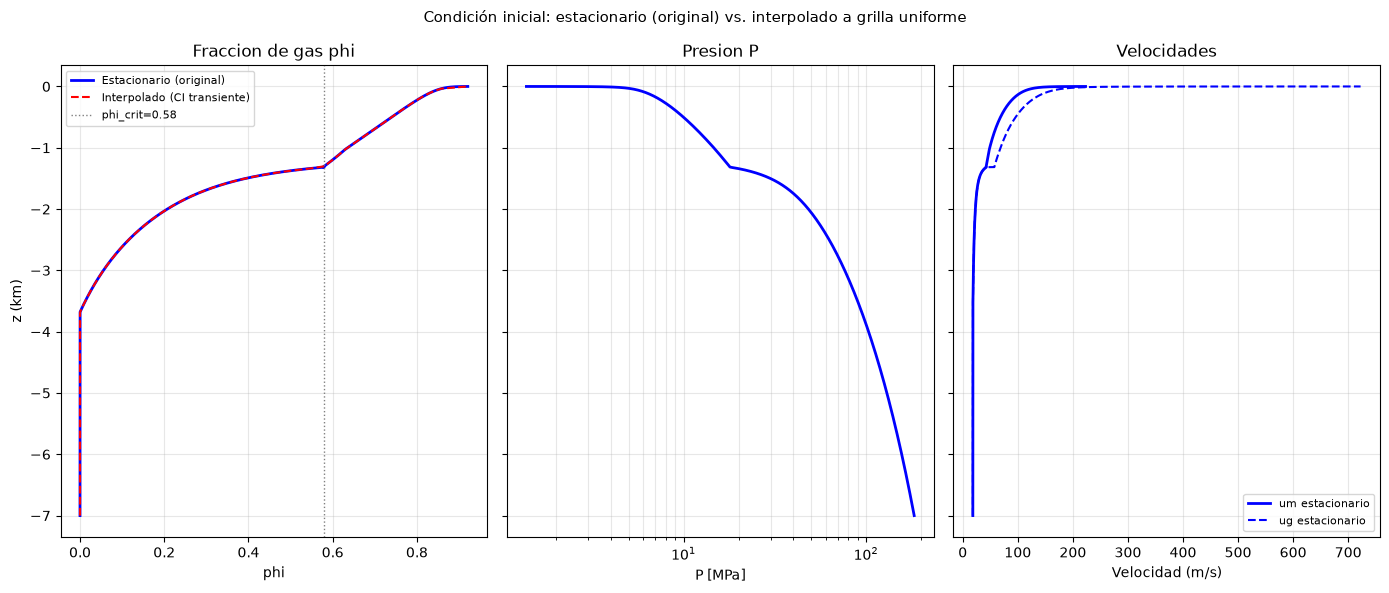

In [5]:
# Comparar perfil estacionario vs. CI interpolada
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
fig.suptitle('Condición inicial: estacionario (original) vs. interpolado a grilla uniforme', fontsize=11)

ax = axes[0]
ax.plot(sol_asc[:,1], zsol_asc/1e3, 'b-', lw=2, label='Estacionario (original)')
ax.plot(phi_ic,       z_uniform/1e3, 'r--', lw=1.5, label='Interpolado (CI transiente)')
ax.axvline(phicrit_calc, color='gray', ls=':', lw=1, label=f'phi_crit={phicrit_calc:.2f}')
ax.set_xlabel('phi')
ax.set_ylabel('z (km)')
ax.set_title('Fraccion de gas phi')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(sol_asc[:,0]/1e6, zsol_asc/1e3, 'b-', lw=2, label='Estacionario')
ax.set_xlabel('P [MPa]')
ax.set_title('Presion P')
ax.grid(True, alpha=0.3, which='both')

ax = axes[2]
ax.plot(sol_asc[:,4], zsol_asc/1e3, 'b-', lw=2, label='um estacionario')
ax.plot(sol_asc[:,5], zsol_asc/1e3, 'b--', lw=1.5, label='ug estacionario')
ax.set_xlabel('Velocidad (m/s)')
ax.set_title('Velocidades')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('IC_estacionaria_interpolada.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Modelo transiente con CI = solución estacionaria

Para esto se expone la CI directamente al solver transiente mediante el argumento
`stationary_ic`. Si el modelo es consistente con el estacionario, los perfiles **no deben
cambiar** (la solución ya es el atractor).

In [6]:
out = RIconduit1D_transient_f(
    radius            = radius1,
    Pressure          = overP1,
    wt                = h2o1,
    Temperature       = T1,
    content_crystal   = xi1,
    phicrit_override  = phicrit_calc,   # phicrit del estacionario
    tau_relax         = 1.0,
    N_z               = N_z,
    T_max             = 300.0,          # 5 minutos: suficiente para ver si deriva
    save_every        = 30,
    CFL               = 0.4,
    stationary_ic     = {
        'phi': phi_ic,
        'Nd' : Nd_ic,
        'x'  : x_ic,
    },
)

══════════════════════════════════════════════════════════════
  RIconduit1D_transient (HEM + q dinámico) — Parámetros
  Pi      = 1.835e+08 Pa     ρm  = 2463 kg/m³
  q(t=0)  = 54440.2 kg/m²/s   τ_relax = 1 s
  N_z     = 200     Δz  = 35.2 m
  T_max   = 300 s     CFL = 0.4
  φ_crit  = 0.58  (fragmentación)
  CI      : solución estacionaria interpolada
  P_vent(t=0) = 1.01 bar  (debe ser ~1 bar)
══════════════════════════════════════════════════════════════
  t =      1.4 s   φ_max = 0.9359   um_vent = 349.98 m/s   ug_vent = 365.81 m/s   P_vent = 1.49 bar   q = 61510 kg/m²/s   nfrag = 41   Δt = 0.04 s
  t =      2.6 s   φ_max = 0.9522   um_vent = 349.98 m/s   ug_vent = 361.99 m/s   P_vent = 1.22 bar   q = 66792 kg/m²/s   nfrag = 44   Δt = 0.04 s
  t =      3.8 s   φ_max = 0.9559   um_vent = 349.98 m/s   ug_vent = 360.64 m/s   P_vent = 1.19 bar   q = 70357 kg/m²/s   nfrag = 46   Δt = 0.04 s
  t =      4.9 s   φ_max = 0.9550   um_vent = 349.98 m/s   ug_vent = 359.61 m/s   P_vent = 1.38 ba

## 4. Comparacion: estacionario vs. transiente en t=0, t_mid, t_final

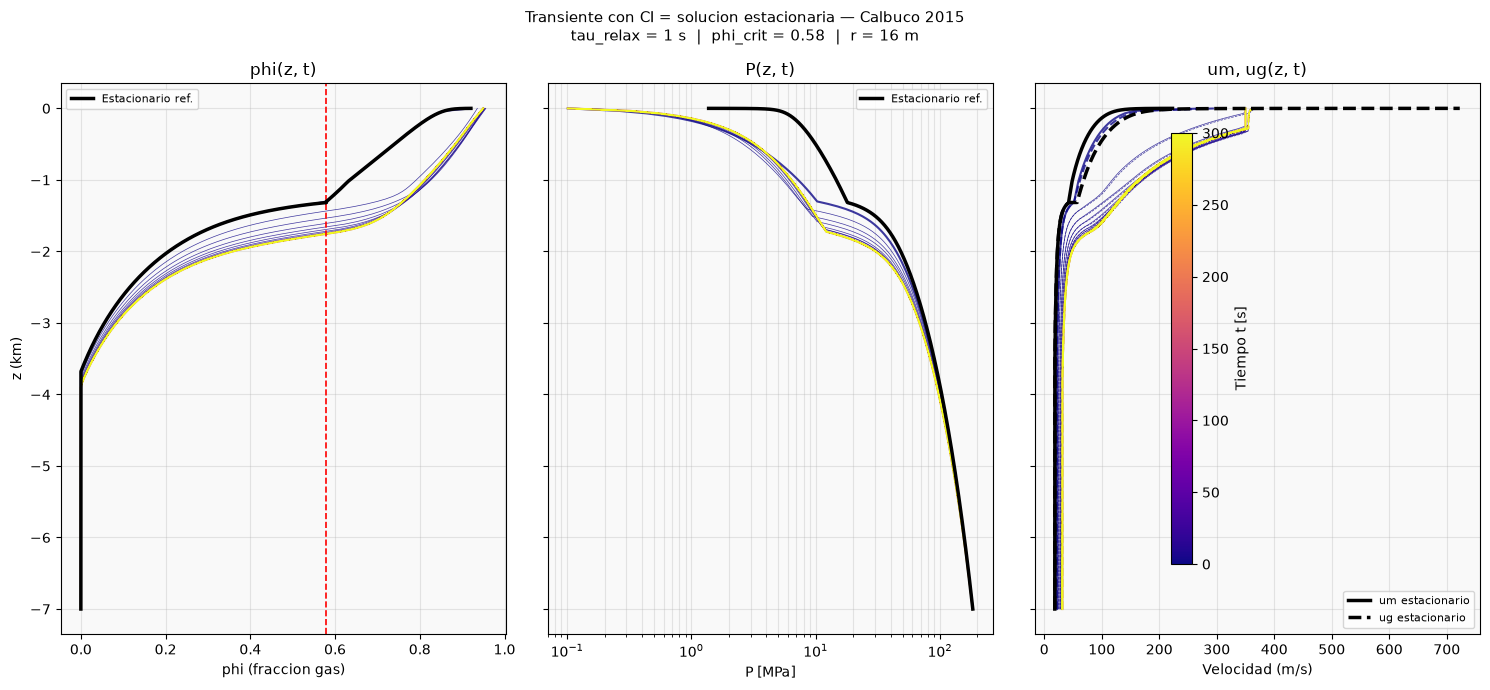

In [7]:
t_save   = out['t_save']
z        = out['z']
phi_hist = out['phi_hist']
P_hist   = out['P_hist']
um_hist  = out['um_hist']
ug_hist  = out['ug_hist']
q_hist   = out['q_hist']
z_km     = z / 1e3

cmap = cm.plasma
norm = plt.Normalize(vmin=t_save.min(), vmax=t_save.max())
sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig.suptitle(
    f'Transiente con CI = solucion estacionaria — Calbuco 2015\n'
    f'tau_relax = 1 s  |  phi_crit = {phicrit_calc:.2f}  |  r = {radius1} m',
    fontsize=11
)

# Referencia: solución estacionaria
for ax in axes:
    ax.set_facecolor('#f9f9f9')

# phi(z, t)
ax = axes[0]
ax.plot(sol_asc[:,1], zsol_asc/1e3, 'k-', lw=2.5, label='Estacionario ref.', zorder=10)
for i, t in enumerate(t_save):
    lw = 1.5 if i in [0, len(t_save)//2, len(t_save)-1] else 0.5
    ax.plot(phi_hist[i], z_km, color=cmap(norm(t)), linewidth=lw, alpha=0.8)
ax.axvline(phicrit_calc, color='red', ls='--', lw=1.2)
ax.set_xlabel('phi (fraccion gas)')
ax.set_ylabel('z (km)')
ax.set_title('phi(z, t)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# P(z, t)
ax = axes[1]
ax.semilogx(sol_asc[:,0]/1e6, zsol_asc/1e3, 'k-', lw=2.5, label='Estacionario ref.', zorder=10)
for i, t in enumerate(t_save):
    lw = 1.5 if i in [0, len(t_save)//2, len(t_save)-1] else 0.5
    ax.semilogx(P_hist[i]/1e6, z_km, color=cmap(norm(t)), linewidth=lw, alpha=0.8)
ax.set_xlabel('P [MPa]')
ax.set_title('P(z, t)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')

# velocidades
ax = axes[2]
ax.plot(sol_asc[:,4], zsol_asc/1e3, 'k-',  lw=2.5, label='um estacionario', zorder=10)
ax.plot(sol_asc[:,5], zsol_asc/1e3, 'k--', lw=2.5, label='ug estacionario', zorder=10)
for i, t in enumerate(t_save):
    lw = 1.5 if i in [0, len(t_save)//2, len(t_save)-1] else 0.5
    c = cmap(norm(t))
    ax.plot(um_hist[i], z_km, color=c, linewidth=lw, alpha=0.8)
    ax.plot(ug_hist[i], z_km, color=c, linewidth=lw, linestyle='--', alpha=0.8)
ax.set_xlabel('Velocidad (m/s)')
ax.set_title('um, ug(z, t)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02, label='Tiempo t [s]')
plt.tight_layout()
plt.savefig('transient_statIC_calbuco2015.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evolucion del flujo masico q(t)

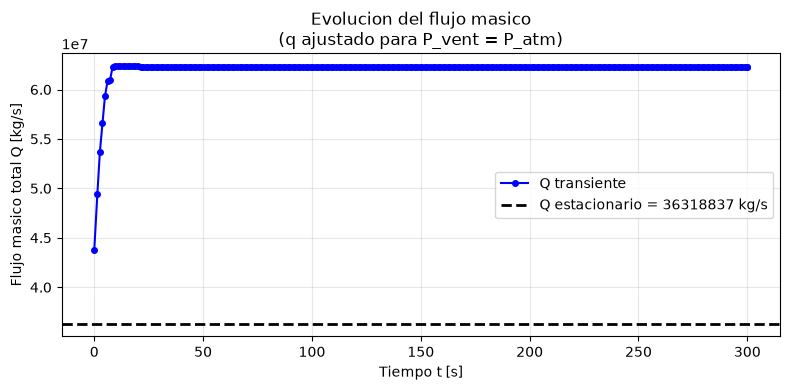

Q estacionario (referencia): 36318836.8 kg/s
Q transiente en t=0        : 43783399.0 kg/s
Q transiente en t_final    : 62307199.7 kg/s
P_vent final               : 1.01 bar


In [8]:
A_conduit = np.pi * radius1**2
Q_hist    = np.array(q_hist) * A_conduit

# Q del estacionario: q_stat = vinicial_conv * rho_ti
rho_ti_stat = result_stat[7]
Q_stat      = vinicial_conv * rho_ti_stat * A_conduit

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(t_save, Q_hist, 'b-o', markersize=4, label='Q transiente')
ax2.axhline(Q_stat, color='k', ls='--', lw=2, label=f'Q estacionario = {Q_stat:.0f} kg/s')
ax2.set_xlabel('Tiempo t [s]')
ax2.set_ylabel('Flujo masico total Q [kg/s]')
ax2.set_title('Evolucion del flujo masico\n(q ajustado para P_vent = P_atm)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q_evol_statIC.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Q estacionario (referencia): {Q_stat:.1f} kg/s')
print(f'Q transiente en t=0        : {Q_hist[0]:.1f} kg/s')
print(f'Q transiente en t_final    : {Q_hist[-1]:.1f} kg/s')
print(f'P_vent final               : {out["P_hist"][-1,-1]/1e5:.2f} bar')

## 6. Resumen: deriva temporal (norma L2 de phi)

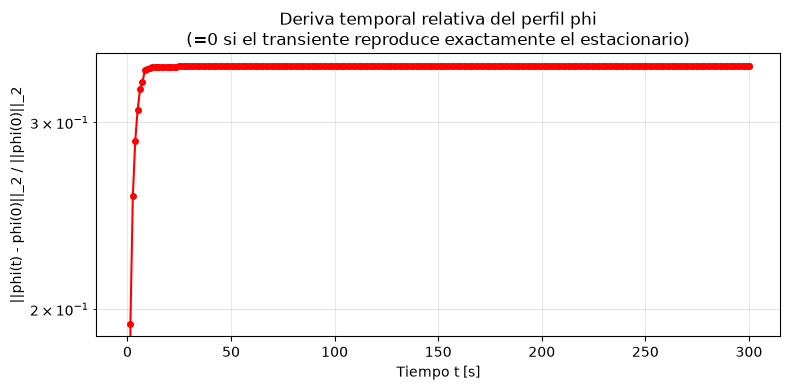

Deriva relativa maxima : 0.3389  (33.89%)
Deriva en t_final      : 0.3389  (33.89%)


In [9]:
# Deriva temporal: ||phi(t) - phi(t=0)||_2  /  ||phi(t=0)||_2
phi0   = phi_hist[0]
drift  = [np.linalg.norm(phi_hist[i] - phi0) / (np.linalg.norm(phi0) + 1e-12)
          for i in range(len(t_save))]

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.semilogy(t_save, drift, 'r-o', markersize=4)
ax3.set_xlabel('Tiempo t [s]')
ax3.set_ylabel('||phi(t) - phi(0)||_2 / ||phi(0)||_2')
ax3.set_title('Deriva temporal relativa del perfil phi\n'
              '(=0 si el transiente reproduce exactamente el estacionario)')
ax3.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('drift_statIC.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Deriva relativa maxima : {max(drift):.4f}  ({max(drift)*100:.2f}%)')
print(f'Deriva en t_final      : {drift[-1]:.4f}  ({drift[-1]*100:.2f}%)')